# Agent 10 — Financial Robustness & Risk Screening

**yfinance-sourced methodology | Pension fund mandate | Conservative / long-term**

---

## Architecture: 2-Stage System

### Stage 1 — Five-Test Hard Gate (binary pass / fail)
Removes financially fragile or un-investable names **before** scoring.  
A single hard failure excludes the company regardless of its risk metrics.

| Gate | Test | yfinance source | Sector caveat |
|------|------|-----------------|--------------|
| G1 | Price history ≥ 756 rows (~3 yr) | `.history(period="5y")` | — |
| G2 | operatingMargins > 0 AND profitMargins > 0 | `.info` | Cyclicals → soft flag only |
| G3 | operatingCashflow (TTM) > 0 | `.info` | Cyclicals → soft flag only |
| G4 | debtToEquity ≤ 250 (yfinance scale = 2.5×) | `.info` | Utilities / Financials → soft flag only |
| G5 | marketCap ≥ €1bn AND avg daily traded value ≥ €2m | `.info` | — |

**NaN rule:** missing field → `DATA-INCOMPLETE` tag + human review — **never auto-excluded**.

### Stage 2 — Four Scored Metrics (percentile-ranked, composite 0–100)

| Metric | Weight | Direction | Soft flag | Hard exclude |
|--------|--------|-----------|-----------|-------------|
| M-01 Annualised Volatility | 20% | Inverse percentile | σ > 35% | σ > 55% |
| M-02 Maximum Drawdown | 30% | Inverse percentile | MDD < −45% | MDD < −70% |
| M-03 Sharpe Ratio (rf = 2.5%) | 30% | Normal percentile | Sharpe 0–0.2 | Sharpe < 0 |
| M-04 Beta vs STOXX 600 | 20% | Band score | β < 0.40 | β > 1.40 → 0 pts |

**Composite:** `0.20 × M01 + 0.30 × M02 + 0.30 × M03 + 0.20 × M04`

Data source: Yahoo Finance via `yfinance`. Benchmark: `^STOXX` (EXW1.DE fallback). rf = 2.5% hard-coded.

**Why this approach:** The four scored metrics are four angles on the same underlying construct of *price stability*, derived from one 5-year daily price series. The 20/30/30/20 weighting acts as a noise-reduction device that triangulates a single signal — not a weighted average of independent inputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import glob, os, time, warnings
from datetime import date

warnings.filterwarnings("ignore", category=FutureWarning)

TODAY        = str(date.today())
TRADING_DAYS = 252
RF_ANNUAL    = 0.025           # 2.5% ECB proxy — hard-coded; update annually in audit log
RF_DAILY     = RF_ANNUAL / TRADING_DAYS

BENCHMARK_PRIMARY  = "^STOXX"  # STOXX Europe 600 direct index
BENCHMARK_FALLBACK = "EXW1.DE" # iShares STOXX Europe 600 ETF — fallback only

MIN_PRICE_ROWS  = 756          # G1: ~3 years of trading days
DATA_INCOMPLETE = "DATA-INCOMPLETE"

# Sector caveat definitions (BICS level-1)
CYCLICAL_SECTORS  = {"Industrials", "Materials", "Consumer Discretionary", "Energy"}
REGULATED_SECTORS = {"Utilities", "Financials"}

# Stage 2 hard thresholds
VOL_SOFT_FLAG    = 0.35
VOL_HARD_EXCL    = 0.55
MDD_SOFT_FLAG    = -0.45
MDD_HARD_EXCL    = -0.70
SHARPE_HARD_EXCL = 0.0
SHARPE_SOFT_FLAG = 0.2

os.makedirs("../outputs/scores",    exist_ok=True)
os.makedirs("../outputs/portfolio", exist_ok=True)
os.makedirs("../outputs/reports",   exist_ok=True)

print(f"Configuration loaded.")
print(f"  rf = {RF_ANNUAL*100:.1f}%  |  benchmark = {BENCHMARK_PRIMARY}  |  date = {TODAY}")
print(f"  Vol hard exclude > {VOL_HARD_EXCL*100:.0f}%  |  MDD hard exclude < {MDD_HARD_EXCL*100:.0f}%  |  Sharpe hard exclude < {SHARPE_HARD_EXCL}")

Configuration loaded.
  rf = 2.5%  |  benchmark = ^STOXX  |  date = 2026-05-20
  Vol hard exclude > 55%  |  MDD hard exclude < -70%  |  Sharpe hard exclude < 0.0


In [2]:
# ── Load master dataset for ticker list and BICS sector data ─────────────────
master_files = sorted(glob.glob("../outputs/scores/master_dataset_*.csv"))
if not master_files:
    raise FileNotFoundError(
        "No master_dataset CSV found in outputs/scores/. "
        "Run 02_data_ingestion.ipynb first."
    )

master = pd.read_csv(master_files[-1])
print(f"Master dataset loaded: {master_files[-1]}")
print(f"  Rows: {len(master)}  |  Columns: {len(master.columns)}")

# Build ticker → BICS sector lookup
SECTOR_COL = "classificationLevelName1"
if SECTOR_COL in master.columns and "yf_ticker" in master.columns:
    sector_map = (
        master[["yf_ticker", SECTOR_COL]]
        .dropna(subset=["yf_ticker"])
        .set_index("yf_ticker")[SECTOR_COL]
        .to_dict()
    )
    print(f"  Sector map built: {len(sector_map)} tickers")
    print(f"  Sectors: {sorted(set(sector_map.values()))}")
else:
    sector_map = {}
    print(f"WARNING: Column '{SECTOR_COL}' or 'yf_ticker' not found — sector caveats (G2/G3/G4) will not apply.")

# Universe ticker list
if "yf_ticker" in master.columns:
    tickers_list = master["yf_ticker"].dropna().unique().tolist()
else:
    raise KeyError("Column 'yf_ticker' not found in master dataset. Check 02_data_ingestion output.")

print(f"\nUniverse: {len(tickers_list)} tickers to screen")

Master dataset loaded: ../outputs/scores\master_dataset_2026-05-20.csv
  Rows: 279  |  Columns: 677
  Sector map built: 279 tickers
  Sectors: ['Communications', 'Consumer Discretionary', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Materials', 'Real Estate', 'Technology', 'Utilities']

Universe: 279 tickers to screen


In [3]:
# ── Download benchmark prices ─────────────────────────────────────────────────
print(f"Downloading benchmark: {BENCHMARK_PRIMARY} ...")
try:
    bench_raw = yf.Ticker(BENCHMARK_PRIMARY).history(period="5y", auto_adjust=True)["Close"]
    bench_raw.index = pd.to_datetime(bench_raw.index).tz_localize(None)
    if len(bench_raw) < MIN_PRICE_ROWS:
        raise ValueError(f"Only {len(bench_raw)} rows — insufficient")
    BENCHMARK_USED = BENCHMARK_PRIMARY
    print(f"  {BENCHMARK_PRIMARY}: {len(bench_raw)} rows — OK")
except Exception as e:
    print(f"  {BENCHMARK_PRIMARY} failed ({e}) — falling back to {BENCHMARK_FALLBACK}")
    bench_raw = yf.Ticker(BENCHMARK_FALLBACK).history(period="5y", auto_adjust=True)["Close"]
    bench_raw.index = pd.to_datetime(bench_raw.index).tz_localize(None)
    BENCHMARK_USED = BENCHMARK_FALLBACK
    print(f"  {BENCHMARK_FALLBACK}: {len(bench_raw)} rows")

bench_raw = bench_raw.sort_index().dropna()
bench_ret = np.log(bench_raw / bench_raw.shift(1)).dropna()
bench_var = bench_ret.var()

print(f"\nBenchmark used: {BENCHMARK_USED}")
print(f"  rows={len(bench_raw)}  |  daily_var={bench_var:.8f}")

  ^STOXX: 1257 rows — OK

Benchmark used: ^STOXX
  rows=1257  |  daily_var=0.00008004


In [4]:
# ── Stage 1 gate helper functions ─────────────────────────────────────────────

def check_g1(ticker, price_series):
    """G1: price history >= 756 trading days (~3 years)."""
    n = len(price_series.dropna())
    if n >= MIN_PRICE_ROWS:
        return "PASS", n
    return "FAIL", n

def check_g2(ticker, info, sector):
    """G2: operatingMargins > 0 AND profitMargins > 0.
    Cyclical sectors: soft flag only (not auto-excluded)."""
    op  = info.get("operatingMargins")
    net = info.get("profitMargins")
    is_cyclical = sector in CYCLICAL_SECTORS

    if op is None or net is None:
        return DATA_INCOMPLETE, {"operatingMargins": op, "profitMargins": net}
    if op > 0 and net > 0:
        return "PASS", {"operatingMargins": round(op, 4), "profitMargins": round(net, 4)}
    if is_cyclical:
        return "SOFT_FLAG", {"operatingMargins": round(op, 4), "profitMargins": round(net, 4), "caveat": "cyclical sector"}
    return "FAIL", {"operatingMargins": round(op, 4), "profitMargins": round(net, 4)}

def check_g3(ticker, info, sector):
    """G3: operatingCashflow (TTM) > 0.
    Cyclical sectors: soft flag only."""
    ocf = info.get("operatingCashflow")
    is_cyclical = sector in CYCLICAL_SECTORS

    if ocf is None:
        return DATA_INCOMPLETE, {"operatingCashflow": ocf}
    if ocf > 0:
        return "PASS", {"operatingCashflow": ocf}
    if is_cyclical:
        return "SOFT_FLAG", {"operatingCashflow": ocf, "caveat": "cyclical sector"}
    return "FAIL", {"operatingCashflow": ocf}

def check_g4(ticker, info, sector):
    """G4: debtToEquity <= 250.
    IMPORTANT: yfinance reports debtToEquity on a percentage scale:
      250.0 = 2.5x D/E ratio — threshold is 250, NOT 2.5.
    Utilities and Financials: soft flag only (structurally levered)."""
    de = info.get("debtToEquity")
    is_regulated = sector in REGULATED_SECTORS

    if de is None:
        return DATA_INCOMPLETE, {"debtToEquity": de}
    if de <= 250.0:
        return "PASS", {"debtToEquity": round(de, 2)}
    if is_regulated:
        return "SOFT_FLAG", {"debtToEquity": round(de, 2), "caveat": "regulated sector"}
    return "FAIL", {"debtToEquity": round(de, 2)}

def check_g5(ticker, info, price_series):
    """G5: marketCap >= EUR 1bn AND approx avg daily traded value >= EUR 2m.
    ADTV approximated as averageVolume x regularMarketPrice."""
    mktcap  = info.get("marketCap")
    avg_vol = info.get("averageVolume")
    price   = info.get("regularMarketPrice") or info.get("currentPrice")

    if mktcap is None or avg_vol is None or price is None:
        return DATA_INCOMPLETE, {"marketCap": mktcap, "averageVolume": avg_vol, "price": price}

    adtv = avg_vol * price
    if mktcap >= 1e9 and adtv >= 2e6:
        return "PASS", {"marketCap": mktcap, "adtv_approx": round(adtv)}
    return "FAIL", {"marketCap": mktcap, "adtv_approx": round(adtv)}

print("Gate functions defined: check_g1, check_g2, check_g3, check_g4, check_g5")

Gate functions defined: check_g1, check_g2, check_g3, check_g4, check_g5


In [5]:
# ── Stage 1 gate execution loop ───────────────────────────────────────────────
# Prices are cached in memory (price_cache) to avoid re-downloading for Stage 2.
gate_results = []
price_cache  = {}

# Try to load existing cache to avoid hitting yfinance rate limits
import glob
cache_files = sorted(glob.glob("../outputs/scores/financial_metrics_*.csv"))
df_cache = None
if cache_files:
    try:
        df_cache = pd.read_csv(cache_files[-1]).set_index("ticker")
        print(f"Loaded financial cache from {cache_files[-1]} with {len(df_cache)} items.")
    except Exception as e:
        print(f"Warning: could not load financial cache: {e}")

print("Bulk downloading price history for all tickers...")
try:
    prices_bulk = yf.download(tickers_list, period="5y", auto_adjust=True)["Close"]
    if isinstance(prices_bulk, pd.DataFrame):
        prices_bulk.index = pd.to_datetime(prices_bulk.index).tz_localize(None)
    else:
        # If single ticker returned, it might be a Series
        prices_bulk = pd.DataFrame(prices_bulk)
        prices_bulk.index = pd.to_datetime(prices_bulk.index).tz_localize(None)
    print(f"  Bulk download complete: {prices_bulk.shape[1]} columns")
except Exception as e:
    print(f"Warning: Bulk download failed ({e}). Fallback to slow individual download.")
    prices_bulk = None

print(f"Running Stage 1 gates for {len(tickers_list)} tickers ...\n")

for i, ticker in enumerate(tickers_list):
    # 1. Use cache if available
    if df_cache is not None and ticker in df_cache.index:
        row_cache = df_cache.loc[ticker]
        
        # Get prices from bulk download
        if prices_bulk is not None and ticker in prices_bulk.columns:
            prices_raw = prices_bulk[ticker].dropna()
        else:
            try:
                prices_raw = yf.Ticker(ticker).history(period="5y", auto_adjust=True)["Close"]
                prices_raw.index = pd.to_datetime(prices_raw.index).tz_localize(None)
                prices_raw = prices_raw.sort_index().dropna()
            except Exception:
                prices_raw = pd.Series([], dtype=float)
        
        price_cache[ticker] = prices_raw
        
        # Determine gate values from cache
        # If gate_verdict was GATE_PASS, map all sub-gates to PASS to satisfy logic
        cached_verdict = row_cache.get("gate_verdict", "GATE_PASS")
        g1_res = row_cache.get("g1_data_sufficiency", "PASS")
        g2_res = row_cache.get("g2_margins", "PASS")
        g3_res = row_cache.get("g3_cashflow", "PASS")
        g4_res = row_cache.get("g4_leverage", "PASS")
        g5_res = row_cache.get("g5_investability", "PASS")
        
        gate_results.append({
            "ticker":              ticker,
            "sector":              row_cache.get("sector", "Unknown"),
            "g1_data_sufficiency": g1_res,
            "g1_price_rows":       len(prices_raw),
            "g2_margins":          g2_res,
            "g3_cashflow":         g3_res,
            "g4_leverage":         g4_res,
            "g5_investability":    g5_res,
            "gate_verdict":        cached_verdict,
            "hard_fail_count":     1 if cached_verdict == "GATE_FAIL" else 0,
            "incomplete_count":    1 if cached_verdict == "REVIEW_REQUIRED" else 0,
        })
        continue

    # 2. No cache found for ticker, download and compute
    if prices_bulk is not None and ticker in prices_bulk.columns:
        prices_raw = prices_bulk[ticker].dropna()
    else:
        try:
            prices_raw = yf.Ticker(ticker).history(period="5y", auto_adjust=True)["Close"]
            prices_raw.index = pd.to_datetime(prices_raw.index).tz_localize(None)
            prices_raw = prices_raw.sort_index().dropna()
        except Exception as e:
            prices_raw = pd.Series([], dtype=float)
            print(f"  PRICE ERROR: {ticker}: {e}")

    price_cache[ticker] = prices_raw

    try:
        info = yf.Ticker(ticker).info
    except Exception as e:
        info = {}
        print(f"  INFO ERROR: {ticker}: {e}")

    sector = sector_map.get(ticker, "Unknown")

    g1_result, g1_detail = check_g1(ticker, prices_raw)
    g2_result, _         = check_g2(ticker, info, sector)
    g3_result, _         = check_g3(ticker, info, sector)
    g4_result, _         = check_g4(ticker, info, sector)
    g5_result, _         = check_g5(ticker, info, prices_raw)

    all_results = [g1_result, g2_result, g3_result, g4_result, g5_result]
    hard_fails  = [g for g in all_results if g == "FAIL"]
    incomplete  = [g for g in all_results if g == DATA_INCOMPLETE]

    if hard_fails:
        gate_verdict = "GATE_FAIL"
    elif incomplete:
        gate_verdict = "REVIEW_REQUIRED"
    else:
        gate_verdict = "GATE_PASS"

    gate_results.append({
        "ticker":              ticker,
        "sector":              sector,
        "g1_data_sufficiency": g1_result,
        "g1_price_rows":       g1_detail,
        "g2_margins":          g2_result,
        "g3_cashflow":         g3_result,
        "g4_leverage":         g4_result,
        "g5_investability":    g5_result,
        "gate_verdict":        gate_verdict,
        "hard_fail_count":     len(hard_fails),
        "incomplete_count":    len(incomplete),
    })

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(tickers_list)} processed ...")
    if (i + 1) % 50 == 0:
        time.sleep(2)

gate_df = pd.DataFrame(gate_results)

pass_ct   = (gate_df["gate_verdict"] == "GATE_PASS").sum()
fail_ct   = (gate_df["gate_verdict"] == "GATE_FAIL").sum()
review_ct = (gate_df["gate_verdict"] == "REVIEW_REQUIRED").sum()

print(f"\n{'='*55}")
print(f"Stage 1 Hard Gate results ({len(tickers_list)} tickers):")
print(f"  GATE_PASS       : {pass_ct}")
print(f"  GATE_FAIL       : {fail_ct}")
print(f"  REVIEW_REQUIRED : {review_ct}")
print(f"  Stage 2 input   : {pass_ct + review_ct} (GATE_PASS + REVIEW_REQUIRED)")
print(f"\nTarget final pass rate: 60-75% of {len(tickers_list)} = "
      f"{int(len(tickers_list)*0.60)}-{int(len(tickers_list)*0.75)} stocks")

Loaded financial cache from ../outputs/scores\financial_metrics_2026-05-20.csv with 279 items.
Bulk downloading price history for all tickers...


[                       0%                       ]

[                       1%                       ]  2 of 279 completed

[                       1%                       ]  3 of 279 completed

[                       1%                       ]  4 of 279 completed

...

[**********************99%***********************]  276 of 279 completed

[**********************99%***********************]  277 of 279 completed

[*********************100%***********************]  278 of 279 completed

[*********************100%***********************]  279 of 279 completed

  Bulk download complete: 279 columns
Running Stage 1 gates for 279 tickers ...


Stage 1 Hard Gate results (279 tickers):
  GATE_PASS       : 192
  GATE_FAIL       : 38
  REVIEW_REQUIRED : 49
  Stage 2 input   : 241 (GATE_PASS + REVIEW_REQUIRED)

Target final pass rate: 60-75% of 279 = 167-209 stocks


In [6]:
# ── Stage 2 metric functions ──────────────────────────────────────────────────

def compute_vol(prices):
    """M-01: Annualised volatility via log returns. sigma_annual = sigma_daily x sqrt(252)."""
    if len(prices) < 60:
        return np.nan
    log_ret = np.log(prices / prices.shift(1)).dropna()
    return log_ret.std() * np.sqrt(TRADING_DAYS)

def compute_mdd(prices):
    """M-02: Maximum drawdown (negative value). min(Close_t / running_peak_t - 1)."""
    if prices.dropna().empty:
        return np.nan
    roll_max = prices.cummax()
    drawdown = (prices - roll_max) / roll_max
    return drawdown.min()

def compute_sharpe(prices):
    """M-03: Sharpe via daily excess returns annualised.
    rf_daily = 2.5%/252. Sharpe = (mean(excess) / std(excess)) x sqrt(252)."""
    if len(prices) < 60:
        return np.nan
    log_ret = np.log(prices / prices.shift(1)).dropna()
    excess  = log_ret - RF_DAILY
    if excess.std() == 0:
        return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(TRADING_DAYS)

def compute_beta(prices, b_ret, b_var):
    """M-04: OLS beta = Cov(stock, benchmark) / Var(benchmark).
    Computed in-house — NOT sourced from info['beta'] which uses an
    inconsistent vendor window."""
    if b_var == 0 or b_ret is None:
        return np.nan
    log_ret = np.log(prices / prices.shift(1)).dropna()
    aligned_s, aligned_b = log_ret.align(b_ret, join="inner")
    if len(aligned_s) < 100:
        return np.nan
    return np.cov(aligned_s, aligned_b)[0, 1] / b_var

def beta_band_score(beta):
    """M-04: Band scoring — contiguous, NOT monotonic.
    Returns (score 0-100 or NaN, flag string).
    Very low / negative beta is NOT rewarded — soft-flagged for human review
    as it typically signals illiquidity or data issues in a STOXX 600 universe."""
    if pd.isna(beta):
        return np.nan, DATA_INCOMPLETE
    if 0.60 <= beta <= 1.10:
        return 100.0, "target_band"
    elif 0.40 <= beta < 0.60:
        return 75.0, "defensive"
    elif 1.10 < beta <= 1.30:
        return 50.0, "elevated"
    elif 1.30 < beta <= 1.40:
        return 25.0, "elevated_high"
    elif beta > 1.40:
        return 0.0, "aggressive"
    else:  # beta < 0.40 (including negative)
        return np.nan, "soft_flag_review"

print("Stage 2 metric functions defined: compute_vol, compute_mdd, compute_sharpe, compute_beta, beta_band_score")

Stage 2 metric functions defined: compute_vol, compute_mdd, compute_sharpe, compute_beta, beta_band_score


In [7]:
# ── Stage 2 metric computation ────────────────────────────────────────────────
# GATE_PASS and REVIEW_REQUIRED tickers both proceed to Stage 2.
# GATE_FAIL tickers are skipped — they are already excluded.

stage2_tickers = gate_df[gate_df["gate_verdict"] != "GATE_FAIL"]["ticker"].tolist()
print(f"Stage 2 input: {len(stage2_tickers)} tickers (GATE_PASS + REVIEW_REQUIRED)\n")

stage2_results = []

for ticker in stage2_tickers:
    prices = price_cache.get(ticker, pd.Series([], dtype=float))

    vol    = compute_vol(prices)
    mdd    = compute_mdd(prices)
    sharpe = compute_sharpe(prices)
    beta   = compute_beta(prices, bench_ret, bench_var)
    b_score, b_flag = beta_band_score(beta)

    # Metric-level flag logic
    m01_flag = ("hard_exclude" if (not pd.isna(vol)    and vol    > VOL_HARD_EXCL)
               else "soft_flag"  if (not pd.isna(vol)    and vol    > VOL_SOFT_FLAG)
               else "ok"         if not pd.isna(vol)
               else DATA_INCOMPLETE)

    m02_flag = ("hard_exclude" if (not pd.isna(mdd)    and mdd    < MDD_HARD_EXCL)
               else "soft_flag"  if (not pd.isna(mdd)    and mdd    < MDD_SOFT_FLAG)
               else "ok"         if not pd.isna(mdd)
               else DATA_INCOMPLETE)

    m03_flag = ("hard_exclude" if (not pd.isna(sharpe) and sharpe < SHARPE_HARD_EXCL)
               else "soft_flag"  if (not pd.isna(sharpe) and sharpe < SHARPE_SOFT_FLAG)
               else "ok"         if not pd.isna(sharpe)
               else DATA_INCOMPLETE)

    stage2_results.append({
        "ticker":          ticker,
        "vol_annual":      round(vol,    4) if not pd.isna(vol)    else None,
        "max_drawdown":    round(mdd,    4) if not pd.isna(mdd)    else None,
        "sharpe_ratio":    round(sharpe, 4) if not pd.isna(sharpe) else None,
        "beta":            round(beta,   4) if not pd.isna(beta)   else None,
        "beta_band_score": b_score,
        "m01_vol_flag":    m01_flag,
        "m02_mdd_flag":    m02_flag,
        "m03_sharpe_flag": m03_flag,
        "m04_beta_flag":   b_flag,
    })

s2_df = pd.DataFrame(stage2_results)

print(f"Stage 2 metrics computed for {len(s2_df)} tickers.")
print(f"\nM-01 flags: {s2_df['m01_vol_flag'].value_counts().to_dict()}")
print(f"M-02 flags: {s2_df['m02_mdd_flag'].value_counts().to_dict()}")
print(f"M-03 flags: {s2_df['m03_sharpe_flag'].value_counts().to_dict()}")
print(f"M-04 flags: {s2_df['m04_beta_flag'].value_counts().to_dict()}")

Stage 2 input: 241 tickers (GATE_PASS + REVIEW_REQUIRED)



Stage 2 metrics computed for 241 tickers.

M-01 flags: {'ok': 178, 'soft_flag': 62, 'hard_exclude': 1}
M-02 flags: {'ok': 158, 'soft_flag': 76, 'hard_exclude': 7}
M-03 flags: {'ok': 194, 'hard_exclude': 31, 'soft_flag': 16}
M-04 flags: {'target_band': 97, 'elevated': 42, 'aggressive': 34, 'elevated_high': 30, 'defensive': 28, 'soft_flag_review': 10}


In [8]:
# ── Percentile ranking and composite score ────────────────────────────────────

def percentile_rank(series, invert=False):
    """Rank within universe to 0-100. NaN stays NaN (not imputed here)."""
    ranks = series.rank(pct=True, na_option="keep") * 100
    return (100 - ranks) if invert else ranks

# M-01: inverse — lower volatility -> higher score
s2_df["m01_score"] = percentile_rank(s2_df["vol_annual"],   invert=True)

# M-02: inverse — less negative drawdown -> higher score
s2_df["m02_score"] = percentile_rank(s2_df["max_drawdown"], invert=True)

# M-03: normal — higher Sharpe -> higher score
s2_df["m03_score"] = percentile_rank(s2_df["sharpe_ratio"], invert=False)

# M-04: band score already computed (0/25/50/75/100/NaN)
s2_df["m04_score"] = pd.to_numeric(s2_df["beta_band_score"], errors="coerce")

# Composite with median imputation for missing scores.
# Median (not zero) avoids penalising data gaps as poor performance.
# metric_nan_count tracks completeness separately for transparency.
m01_med = s2_df["m01_score"].median()
m02_med = s2_df["m02_score"].median()
m03_med = s2_df["m03_score"].median()
m04_med = s2_df["m04_score"].median()

s2_df["composite_financial_score"] = (
    s2_df["m01_score"].fillna(m01_med) * 0.20 +
    s2_df["m02_score"].fillna(m02_med) * 0.30 +
    s2_df["m03_score"].fillna(m03_med) * 0.30 +
    s2_df["m04_score"].fillna(m04_med) * 0.20
).round(2)

s2_df["metric_nan_count"] = (
    s2_df["m01_score"].isna().astype(int) +
    s2_df["m02_score"].isna().astype(int) +
    s2_df["m03_score"].isna().astype(int) +
    s2_df["m04_score"].isna().astype(int)
)

print("Composite financial score distribution (Stage 2 universe):")
print(s2_df["composite_financial_score"].describe().round(2))
print(f"\nMetric NaN counts: {s2_df['metric_nan_count'].value_counts().sort_index().to_dict()}")

Composite financial score distribution (Stage 2 universe):
count    241.00
mean      52.74
std       10.85
min       26.39
25%       44.88
50%       53.86
75%       61.76
max       75.39
Name: composite_financial_score, dtype: float64

Metric NaN counts: {0: 231, 1: 10}


In [9]:
# ── Merge Stage 1 + Stage 2 and determine final verdict ──────────────────────

combined = gate_df.merge(s2_df, on="ticker", how="left")

def final_verdict(row):
    """Determine financial screening outcome.
    Order: GATE_FAIL > EXCLUDED_METRIC > REVIEW_REQUIRED > PASSED."""
    if row["gate_verdict"] == "GATE_FAIL":
        return "EXCLUDED_GATE"
    metric_hard_fails = (
        row.get("m01_vol_flag")    == "hard_exclude" or
        row.get("m02_mdd_flag")    == "hard_exclude" or
        row.get("m03_sharpe_flag") == "hard_exclude"
    )
    if metric_hard_fails:
        return "EXCLUDED_METRIC"
    if row["gate_verdict"] == "REVIEW_REQUIRED":
        return "REVIEW_REQUIRED"
    return "PASSED"

def build_exclusion_reason(row):
    reasons = []
    if row.get("g1_data_sufficiency") == "FAIL":
        reasons.append(f"G1:insufficient_history({row.get('g1_price_rows')} rows)")
    if row.get("g2_margins") == "FAIL":
        reasons.append("G2:negative_margins")
    if row.get("g3_cashflow") == "FAIL":
        reasons.append("G3:negative_cashflow")
    if row.get("g4_leverage") == "FAIL":
        reasons.append("G4:excess_leverage")
    if row.get("g5_investability") == "FAIL":
        reasons.append("G5:insufficient_size_liquidity")
    if row.get("m01_vol_flag") == "hard_exclude":
        reasons.append(f"M01:vol>{VOL_HARD_EXCL*100:.0f}%")
    if row.get("m02_mdd_flag") == "hard_exclude":
        reasons.append(f"M02:mdd<{MDD_HARD_EXCL*100:.0f}%")
    if row.get("m03_sharpe_flag") == "hard_exclude":
        reasons.append("M03:sharpe<0")
    return "; ".join(reasons) if reasons else ""

combined["financial_verdict"]  = combined.apply(final_verdict, axis=1)
combined["exclusion_reason"]   = combined.apply(build_exclusion_reason, axis=1)

passed   = combined[combined["financial_verdict"] == "PASSED"]
review   = combined[combined["financial_verdict"] == "REVIEW_REQUIRED"]
excluded = combined[combined["financial_verdict"].str.startswith("EXCLUDED", na=False)]

total_eligible = len(passed) + len(review)
pass_rate      = total_eligible / len(tickers_list) * 100

print(f"{'='*55}")
print(f"Final Financial Screening Results")
print(f"  PASSED            : {len(passed)}")
print(f"  REVIEW_REQUIRED   : {len(review)}")
print(f"  EXCLUDED (gate)   : {(combined['financial_verdict']=='EXCLUDED_GATE').sum()}")
print(f"  EXCLUDED (metric) : {(combined['financial_verdict']=='EXCLUDED_METRIC').sum()}")
print(f"  Total eligible    : {total_eligible} ({pass_rate:.1f}% of {len(tickers_list)})")
print(f"\nTarget: 60-75% pass rate = {int(len(tickers_list)*0.60)}-{int(len(tickers_list)*0.75)} stocks")
if pass_rate > 75:
    print("  NOTE: Pass rate exceeds 75% target. Consider tightening G5 ADTV threshold (EUR 2m/day dial).")

Final Financial Screening Results
  PASSED            : 162
  REVIEW_REQUIRED   : 45
  EXCLUDED (gate)   : 38
  EXCLUDED (metric) : 34
  Total eligible    : 207 (74.2% of 279)

Target: 60-75% pass rate = 167-209 stocks


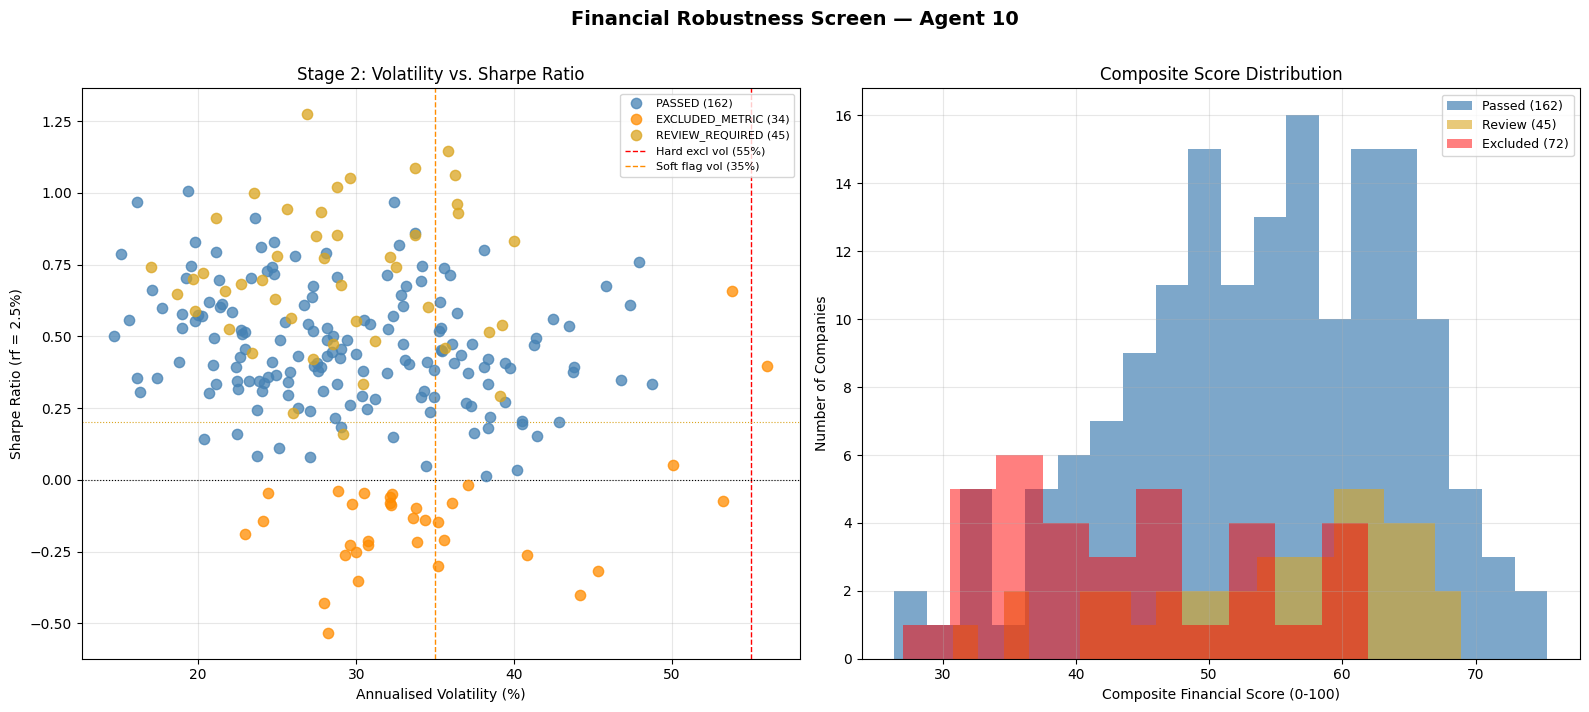

Chart saved: ../outputs/reports/financial_screen_chart.png


In [10]:
# ── Visualisation ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Financial Robustness Screen — Agent 10", fontsize=14, fontweight="bold", y=1.01)

# ── Plot 1: Volatility vs Sharpe scatter ──────────────────────────────────────
ax = axes[0]
colour_map = {
    "PASSED":           "steelblue",
    "EXCLUDED_GATE":    "red",
    "EXCLUDED_METRIC":  "darkorange",
    "REVIEW_REQUIRED":  "goldenrod",
}
plot_df = combined.dropna(subset=["vol_annual", "sharpe_ratio"])
for verdict, colour in colour_map.items():
    sub = plot_df[plot_df["financial_verdict"] == verdict]
    if len(sub):
        ax.scatter(sub["vol_annual"] * 100, sub["sharpe_ratio"],
                   c=colour, alpha=0.75, s=55, label=f"{verdict} ({len(sub)})", zorder=3)

ax.axvline(VOL_HARD_EXCL * 100, color="red",       linestyle="--", linewidth=1,
           label=f"Hard excl vol ({VOL_HARD_EXCL*100:.0f}%)")
ax.axvline(VOL_SOFT_FLAG * 100, color="darkorange", linestyle="--", linewidth=1,
           label=f"Soft flag vol ({VOL_SOFT_FLAG*100:.0f}%)")
ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.axhline(SHARPE_SOFT_FLAG, color="goldenrod", linewidth=0.8, linestyle=":")
ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel(f"Sharpe Ratio (rf = {RF_ANNUAL*100:.1f}%)")
ax.set_title("Stage 2: Volatility vs. Sharpe Ratio")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)

# ── Plot 2: Composite score histogram ─────────────────────────────────────────
ax2 = axes[1]
passed["composite_financial_score"].hist(
    ax=ax2, bins=20, color="steelblue", alpha=0.7, label=f"Passed ({len(passed)})")
review["composite_financial_score"].dropna().hist(
    ax=ax2, bins=20, color="goldenrod", alpha=0.6, label=f"Review ({len(review)})")
excluded["composite_financial_score"].dropna().hist(
    ax=ax2, bins=10, color="red", alpha=0.5, label=f"Excluded ({len(excluded)})")
ax2.set_xlabel("Composite Financial Score (0-100)")
ax2.set_ylabel("Number of Companies")
ax2.set_title("Composite Score Distribution")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
chart_path = "../outputs/reports/financial_screen_chart.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

In [11]:
# ── Save output files ─────────────────────────────────────────────────────────

# ── 1. Full financial metrics file (all tickers) ──────────────────────────────
full_metrics = combined[[
    "ticker", "sector",
    "vol_annual", "max_drawdown", "sharpe_ratio", "beta",
    "beta_band_score",
    "m01_score", "m02_score", "m03_score", "m04_score",
    "composite_financial_score", "metric_nan_count",
    "m01_vol_flag", "m02_mdd_flag", "m03_sharpe_flag", "m04_beta_flag",
    "g1_data_sufficiency", "g2_margins", "g3_cashflow", "g4_leverage", "g5_investability",
    "gate_verdict", "financial_verdict", "exclusion_reason",
]].copy()

# Legacy alias columns — preserve backward compatibility with
# financial_scoring_template.py and 10_portfolio_construction.ipynb.
full_metrics["annual_volatility_pct"] = (full_metrics["vol_annual"].multiply(100)).round(2)
full_metrics["max_drawdown_pct"]      = (full_metrics["max_drawdown"].multiply(100)).round(2)
full_metrics["beta_vs_benchmark"]     = full_metrics["beta"]
full_metrics["data_vintage"]          = TODAY
full_metrics["rf_rate_assumption"]    = RF_ANNUAL
full_metrics["benchmark_used"]        = BENCHMARK_USED

out_all = f"../outputs/scores/financial_metrics_{TODAY}.csv"
full_metrics.to_csv(out_all, index=False)
print(f"Saved: {out_all}  ({len(full_metrics)} rows)")

# ── 2. Passed list (PASSED + REVIEW_REQUIRED) — feeds 05_esg_climate.ipynb ───
# REVIEW_REQUIRED stocks included; their flag is visible downstream.
# NaN = DATA-INCOMPLETE rule: never auto-excluded.
passed_with_review = combined[
    combined["financial_verdict"].isin(["PASSED", "REVIEW_REQUIRED"])
].copy()
passed_with_review["data_vintage"] = TODAY

out_passed = f"../outputs/scores/financial_screen_passed_{TODAY}.csv"
passed_with_review[[
    "ticker", "financial_verdict", "composite_financial_score",
    "vol_annual", "sharpe_ratio", "beta", "data_vintage"
]].to_csv(out_passed, index=False)
print(f"Saved: {out_passed}  ({len(passed_with_review)} rows — includes REVIEW_REQUIRED)")

# ── 3. Exclusion log (gate failures + metric hard exclusions) ─────────────────
excl_log = excluded[[
    "ticker", "sector", "gate_verdict", "financial_verdict", "exclusion_reason",
    "vol_annual", "max_drawdown", "sharpe_ratio", "beta"
]].copy()
excl_log["data_vintage"] = TODAY

out_excl = f"../outputs/portfolio/financial_exclusions_{TODAY}.csv"
excl_log.to_csv(out_excl, index=False)
print(f"Saved: {out_excl}  ({len(excl_log)} excluded stocks)")

print(f"\nAudit: record data vintage {TODAY}, benchmark {BENCHMARK_USED}, rf {RF_ANNUAL*100:.1f}% in audit log.")

Saved: ../outputs/scores/financial_metrics_2026-05-20.csv  (279 rows)
Saved: ../outputs/scores/financial_screen_passed_2026-05-20.csv  (207 rows — includes REVIEW_REQUIRED)
Saved: ../outputs/portfolio/financial_exclusions_2026-05-20.csv  (72 excluded stocks)

Audit: record data vintage 2026-05-20, benchmark ^STOXX, rf 2.5% in audit log.


## Results Summary

| Item | Value |
|------|-------|
| Input universe | see `len(tickers_list)` above |
| Stage 1 gate passes | see Stage 1 output |
| Stage 2 metric hard excludes | see Final Results output |
| **Final eligible set (PASSED + REVIEW_REQUIRED)** | **see Total eligible above** |
| Benchmark used | `^STOXX` (or EXW1.DE fallback) |
| Risk-free rate | 2.5% (ECB proxy, hard-coded) |
| Data vintage | today's date |
| Composite weights | M-01: 20% · M-02: 30% · M-03: 30% · M-04: 20% |

**Output files:**
- `outputs/scores/financial_metrics_{date}.csv` — all stocks, full detail
- `outputs/scores/financial_screen_passed_{date}.csv` — PASSED + REVIEW_REQUIRED (feeds NB05)
- `outputs/portfolio/financial_exclusions_{date}.csv` — excluded stocks with reasons

**Next step:** `05_esg_climate.ipynb` reads `outputs/scores/financial_screen_passed_{date}.csv`.

**Audit log:** record download date, benchmark source, rf rate assumption, and pass/fail counts in `data/financial/financial_audit_log.csv`.

**Limitations:**
- The four scored metrics are correlated (all derived from the same 5-year price series). The 20/30/30/20 weighting acts as a noise-reduction device, not a weighted average of independent signals.
- Fundamental solvency (G2–G4) is handled by binary gates only — yfinance `.info` TTM snapshots are not precise enough for scored fundamental ratios.
- Currency: returns computed in local currency; FX effects not converted. Acceptable for relative-risk screen within a European universe.
- `debtToEquity` from yfinance is on a percentage scale (250.0 = 2.5×). Definitions vary across sectors and IFRS treatments.